# Implementing a Basic Model to Diagnose MS from MRI Scans

TWorkflow for building a simple deep learning model to classify MRI images as either Multiple Sclerosis (MS) or Not (Control).

## 1. Import Required Libraries

Importing essential libraries for data handling, image processing, visualization, and deep learning.

In [1]:
# Data handling and visualization
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Utility
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

## 2. Download and Prepare MRI Dataset

Downloading the MRI dataset from Kaggle using kagglehub and setting up/verifying the directory structure.

Dataset url:https://www.kaggle.com/datasets/buraktaci/multiple-sclerosis/data

In [2]:
# Download dataset from Kaggle using kagglehub
import kagglehub

# Set custom download directory
os.environ["KAGGLEHUB_CACHE"] = "../../data/raw"

# Download if not already present
if not os.listdir("../../data/raw"):
    path = kagglehub.dataset_download("buraktaci/multiple-sclerosis")
    print("Dataset downloaded to:", path)
else:
    print("Dataset already exists in ../../data/raw")
    path = "../../data/raw/datasets/buraktaci/multiple-sclerosis/versions/1/MS/"

# List available categories
categories = os.listdir(path)
print("Available categories:", categories)

Dataset already exists in ../../data/raw
Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']


## 3. Visualize Sample MRI Images

Displaying random samples of control and MS MRI images to visualise the data.

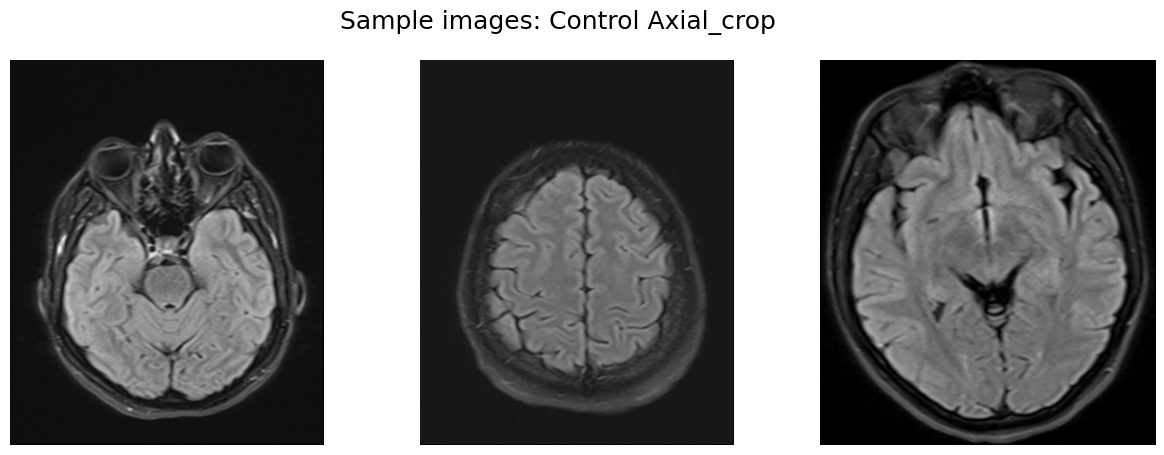

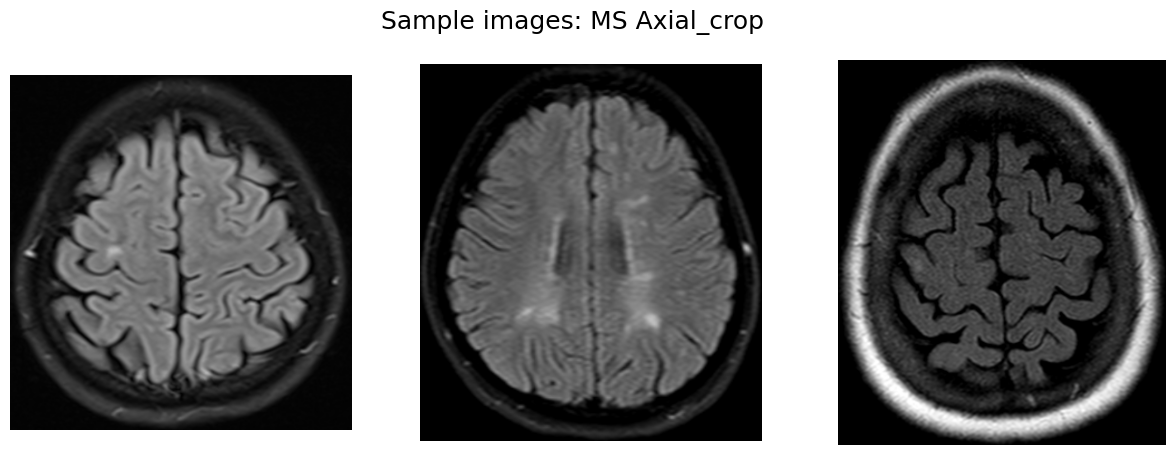

In [3]:
# Define image categories
control_axial = "Control Axial_crop"
ms_axial = "MS Axial_crop"

control_sagittal = "Control Saggital_crop"
ms_sagittal = "MS Saggital_crop"

classes = [control_axial, ms_axial]
# classes = [control_sagittal, ms_sagittal]

# Visualize 3 random images from each category
for cat in classes:
    image_dir = os.path.join(path, cat)
    images = os.listdir(image_dir)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sample images: {cat}', fontsize=18)
    for i in range(3):
        idx = np.random.randint(0, len(images))
        img = np.array(Image.open(os.path.join(image_dir, images[idx])))
        ax[i].imshow(img, cmap='gray')
        ax[i].axis('off')
    plt.show()

## 4. Preprocess MRI Images

Resize images, normalize pixel values, and encode labels for model input. Optionally, augment data for better generalization.

In [5]:
# Parameters
IMG_SIZE = (224, 224)

def load_images_and_labels(classes, path, img_size):
    images = []
    labels = []
    for label, cat in enumerate(classes):
        image_dir = os.path.join(path, cat)
        for fname in os.listdir(image_dir):
            img_path = os.path.join(image_dir, fname)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize(img_size)
                img_array = np.array(img) / 255.0  # Normalize
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    return np.array(images), np.array(labels)

X, y = load_images_and_labels(classes, path, IMG_SIZE)
print(f"Loaded {X.shape[0]} images. Shape: {X.shape}")

Loaded 1652 images. Shape: (1652, 224, 224)


In [9]:
# Optionally, expand dimensions for CNN input
X = X[..., np.newaxis]  # Shape: (num_samples, 128, 128, 1)

## 5. Split Data into Train and Test Sets

Divide the dataset into training and testing sets.

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 1321, Testing samples: 331


## 6. Build a Basic CNN Model

Define a simple convolutional neural network for binary classification (MS vs Control).

In [7]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\markm\anaconda3\envs\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,962,881 (45.63 MB)

 Trainable params: 11,962,881 (45.63 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

Train the CNN model on the training data, monitor loss and accuracy, and use validation data for early stopping.

In [ ]:
# Train model
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    # callbacks=[early_stop]
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9924 - loss: 0.0406 - val_accuracy: 0.8038 - val_loss: 0.4745
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9924 - loss: 0.0422 - val_accuracy: 0.8415 - val_loss: 0.4690
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.8491 - val_loss: 0.4742
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.8377 - val_loss: 0.5481
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8415 - val_loss: 0.5191
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8415 - val_loss: 0.5593
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8566 - val_loss: 0.5554
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.

## 8. Evaluate Model Performance

Assess the model's accuracy, precision, recall, and confusion matrix on the test set.

In [12]:
# Predict on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Accuracy: 0.8670694864048338
Precision: 0.8706896551724138
Recall: 0.7769230769230769
Confusion Matrix:
 [[186  15]
 [ 29 101]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.89       201
           1       0.87      0.78      0.82       130

    accuracy                           0.87       331
   macro avg       0.87      0.85      0.86       331
weighted avg       0.87      0.87      0.87       331



## 9. Make Predictions on Test Images

Use the trained model to predict MS/control on unseen MRI images and visualize the results.

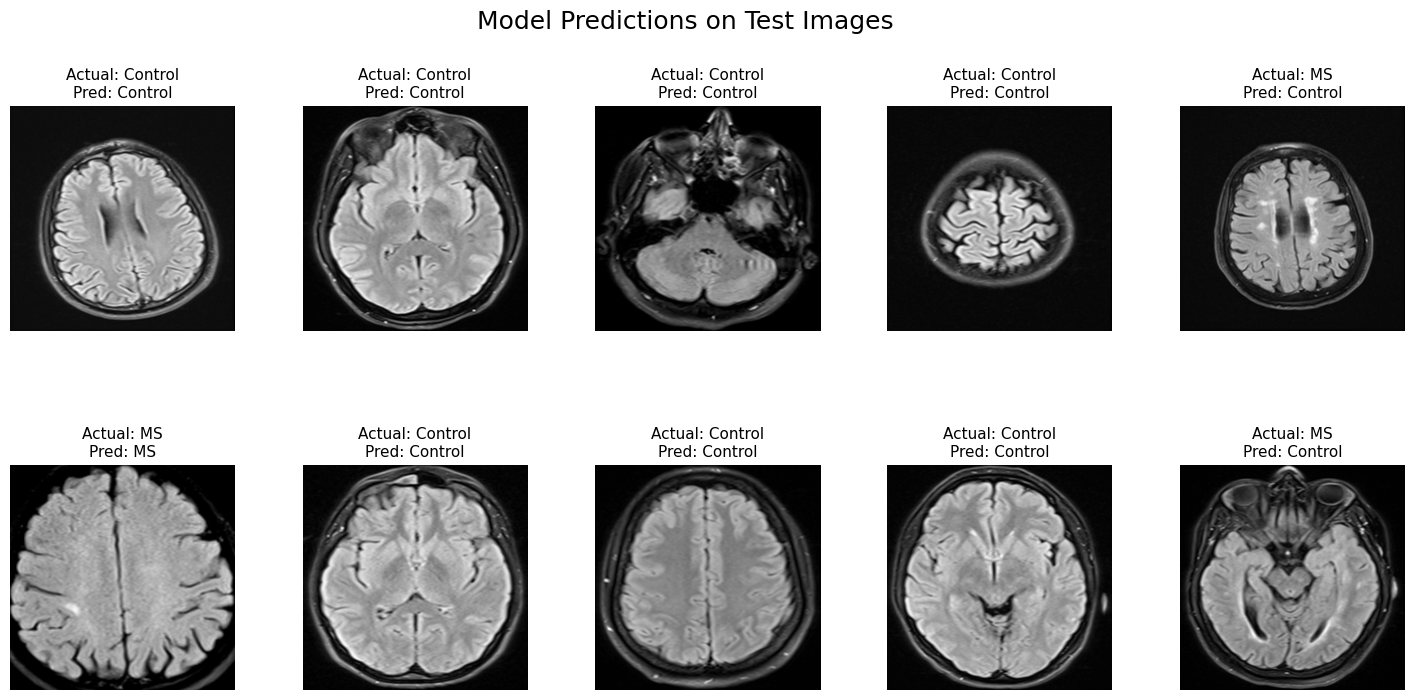

In [13]:
# Visualize predictions on random test images (2 rows of 5 images, with spacing)
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
for i, idx in enumerate(indices):
    row = i // 5
    col = i % 5
    img = X_test[idx].squeeze()
    true_label = "MS" if y_test[idx] == 1 else "Control"
    pred_label = "MS" if y_pred[idx] == 1 else "Control"
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"Actual: {true_label}\nPred: {pred_label}", fontsize=11)
    axes[row, col].axis('off')
plt.suptitle("Model Predictions on Test Images", fontsize=18)
plt.show()